## Ridge Regularization
* Used to solve overfitting
* Types:
* * Ridge (L2)
  * Lasso (L1)
  * ElasticNet
* Loss Function : L = SUM((yi - yi_hat)^2) + {lambda*m^2}-> regularization term


## for line perfectly passing through points (1, 2.3) and (3, 5.3) : taking lambda = 1
* y = 1.5*X + 0.8 => 0 + (0.5)^2 = 2.25 -> Loss of Ln
* y = 0.9*X + 1.5 => (2.3 - 0.9 - 1.5)^2 + (5.3 - 2.7 - 1.5)^2 + (0.9)^2 = 2.03 -> loss of Lr

### for higher dimension curves : regularization term : lambda * (m1^2 + m2^2 + m3^2 + ...) called as L2 norm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

In [4]:
X = data.data
y = data.target

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [8]:
lr.fit(X_train , y_train)

LinearRegression()

In [9]:
y_pred = lr.predict(X_test)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2", r2_score(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 0.4526027629719195
RMSE 53.85344583676593


## Ridge Regression

In [12]:
from sklearn.linear_model import Ridge
R = Ridge(alpha=0.0001)

In [13]:
R.fit(X_train, y_train)

Ridge(alpha=0.0001)

In [14]:
y_pred1 = R.predict(X_test)

In [15]:
print("R2 : ", r2_score(y_test, y_pred))
print("RMSE : ", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 :  0.4526027629719195
RMSE :  53.85344583676593


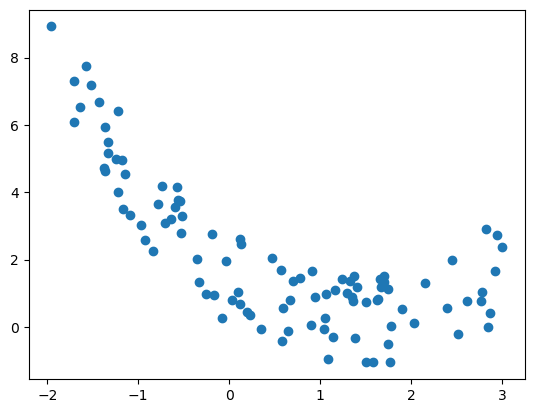

In [17]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7*x1**2 - 2*x1 + 3*np.random.rand(m, 1)

plt.scatter(x1, x2)
plt.show()

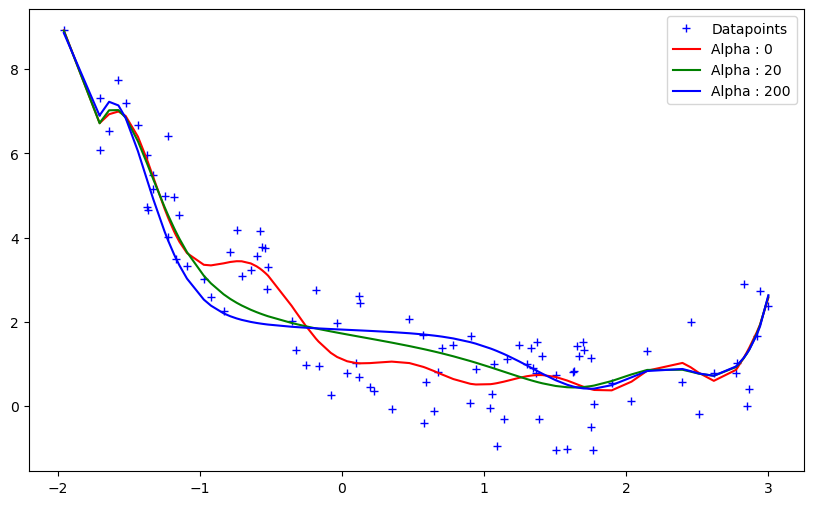

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_pred_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])

    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]

cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_pred_ridge(x1, x2, alpha)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:,0])], c, label = 'Alpha : {}'.format(alpha))

plt.legend()
plt.show()

* * high slope -> overfitting
* * low slope -> underfitting